In [1]:
import pandas as pd

df = pd.read_csv("../data/hillstrom.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (64000, 12)

Columns:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


In [2]:
print("Segment values:")
print(df["segment"].value_counts())

print("\nConversion:")
print(df["conversion"].value_counts())

print("\nVisit:")
print(df["visit"].value_counts())

print("\nData types:")
print(df.dtypes)

Segment values:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Conversion:
conversion
0    63422
1      578
Name: count, dtype: int64

Visit:
visit
0    54606
1     9394
Name: count, dtype: int64

Data types:
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())

Missing values:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Duplicate rows: 6562

Unique values:
recency               12
history_segment        7
history            34833
mens                   2
womens                 2
zip_code               3
newbie                 2
channel                3
segment                3
visit                  2
conversion             2
spend                429
dtype: int64


In [4]:
print("Total rows:", len(df))
print("Unique rows:", df.drop_duplicates().shape[0])
print("Duplicate rows:", df.duplicated().sum())

print("\nDuplicate percentage:",
      round(df.duplicated().mean() * 100, 2), "%")

print("\nExample duplicate rows:")
print(df[df.duplicated(keep=False)].sort_values(
    by=["recency", "history", "segment"]
).head(10))

Total rows: 64000
Unique rows: 57438
Duplicate rows: 6562

Duplicate percentage: 10.25 %

Example duplicate rows:
      recency history_segment  history  mens  womens   zip_code  newbie  \
163         1    1) $0 - $100    29.99     0       1      Urban       1   
270         1    1) $0 - $100    29.99     1       0      Rural       1   
393         1    1) $0 - $100    29.99     1       0      Urban       1   
748         1    1) $0 - $100    29.99     1       0      Rural       1   
755         1    1) $0 - $100    29.99     1       0  Surburban       0   
979         1    1) $0 - $100    29.99     0       1  Surburban       0   
1179        1    1) $0 - $100    29.99     1       0      Rural       0   
1649        1    1) $0 - $100    29.99     0       1  Surburban       0   
1749        1    1) $0 - $100    29.99     0       1      Urban       0   
1972        1    1) $0 - $100    29.99     1       0      Rural       0   

     channel      segment  visit  conversion  spend  
163   

In [5]:
print("Conversions without visit:")
print(((df["conversion"] == 1) & (df["visit"] == 0)).sum())

print("\nPositive spend without conversion:")
print(((df["spend"] > 0) & (df["conversion"] == 0)).sum())

print("\nNegative spend:")
print((df["spend"] < 0).sum())

print("\nZero spend with conversion:")
print(((df["spend"] == 0) & (df["conversion"] == 1)).sum())

Conversions without visit:
0

Positive spend without conversion:
0

Negative spend:
0

Zero spend with conversion:
0


In [6]:
clean_df = df.copy()

print("Original shape:", df.shape)
print("Clean dataset shape:", clean_df.shape)

Original shape: (64000, 12)
Clean dataset shape: (64000, 12)


In [7]:
clean_df.to_csv("../data/hillstrom_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [8]:
print("Descriptive Statistics:")
display(clean_df.describe())

Descriptive Statistics:


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [9]:
print("Campaign Distribution:")
display(clean_df["segment"].value_counts())

print("\nAverage Spend by Campaign:")
display(clean_df.groupby("segment")["spend"].mean())

Campaign Distribution:


segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


Average Spend by Campaign:


segment
Mens E-Mail      1.422617
No E-Mail        0.652789
Womens E-Mail    1.077202
Name: spend, dtype: float64

In [10]:
print("=== DATASET OVERVIEW ===")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\n=== CAMPAIGN DISTRIBUTION ===")
print(clean_df["segment"].value_counts())

print("\n=== KEY METRICS BY CAMPAIGN ===")

summary = clean_df.groupby("segment").agg(
    customers=("segment", "size"),
    visits=("visit", "sum"),
    conversions=("conversion", "sum"),
    total_spend=("spend", "sum")
)

summary["visit_rate"] = summary["visits"] / summary["customers"] * 100
summary["conversion_rate"] = summary["conversions"] / summary["customers"] * 100
summary["conversion_from_visit"] = (
    summary["conversions"] / summary["visits"] * 100
)
summary["revenue_per_customer"] = (
    summary["total_spend"] / summary["customers"]
)

display(summary.round(3))

=== DATASET OVERVIEW ===
Rows: 64000
Columns: 12

=== CAMPAIGN DISTRIBUTION ===
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

=== KEY METRICS BY CAMPAIGN ===


,customers,visits,conversions,total_spend,visit_rate,conversion_rate,conversion_from_visit,revenue_per_customer
segment,,,,,,,,
Mens E-Mail,21307,3894,267,30311.69,18.276,1.253,6.857,1.423
No E-Mail,21306,2262,122,13908.33,10.617,0.573,5.393,0.653
Womens E-Mail,21387,3238,189,23038.11,15.140,0.884,5.837,1.077


In [11]:
import os

os.makedirs("../visualizations", exist_ok=True)

print("Visualization folder ready.")

Visualization folder ready.


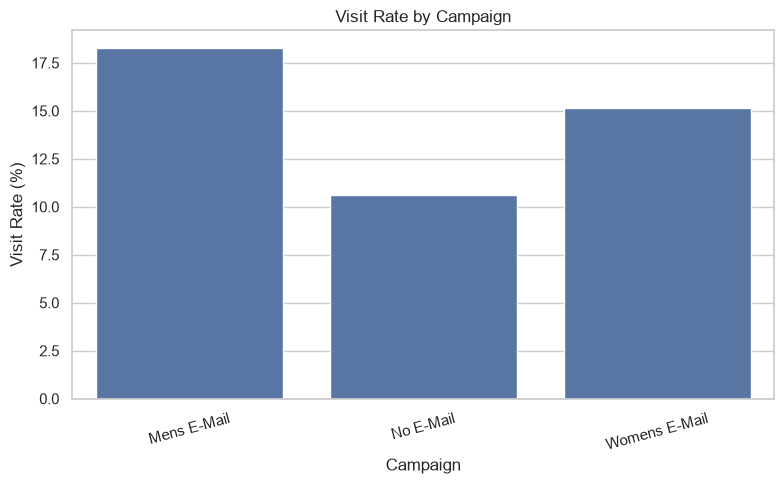

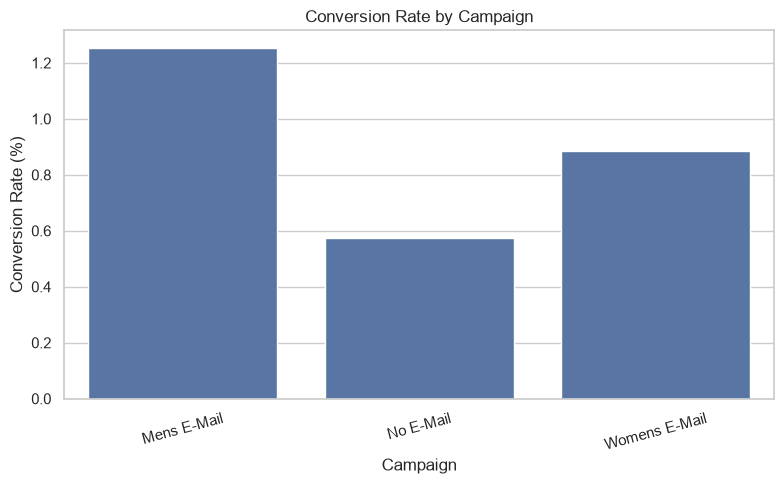

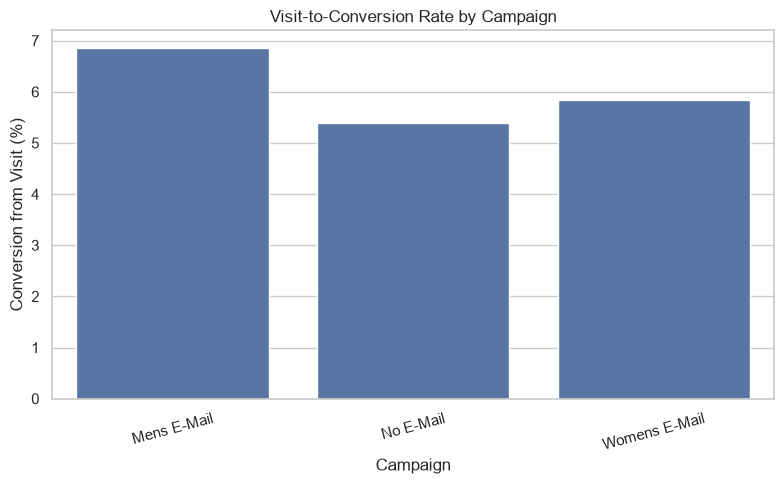

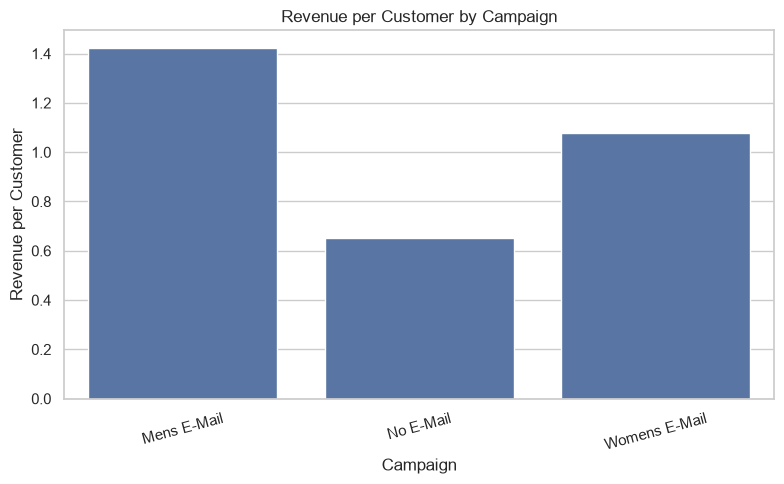

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Visit Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="visit_rate")
plt.title("Visit Rate by Campaign")
plt.ylabel("Visit Rate (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/01_visit_rate.png", dpi=300)
plt.show()

# 2. Conversion Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="conversion_rate")
plt.title("Conversion Rate by Campaign")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/02_conversion_rate.png", dpi=300)
plt.show()

# 3. Conversion from Visit
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="conversion_from_visit")
plt.title("Visit-to-Conversion Rate by Campaign")
plt.ylabel("Conversion from Visit (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4. Revenue per Customer
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="revenue_per_customer")
plt.title("Revenue per Customer by Campaign")
plt.ylabel("Revenue per Customer")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/04_revenue_per_customer.png", dpi=300)
plt.show()

In [13]:
clean_df["experiment_group"] = clean_df["segment"].apply(
    lambda x: "Control" if x == "No E-Mail" else "Treatment"
)

print(clean_df["experiment_group"].value_counts())

experiment_group
Treatment    42694
Control      21306
Name: count, dtype: int64


In [14]:
ab_summary = clean_df.groupby("experiment_group").agg(
    customers=("experiment_group", "size"),
    visits=("visit", "sum"),
    conversions=("conversion", "sum"),
    total_spend=("spend", "sum")
)

ab_summary["visit_rate"] = (
    ab_summary["visits"] / ab_summary["customers"] * 100
)

ab_summary["conversion_rate"] = (
    ab_summary["conversions"] / ab_summary["customers"] * 100
)

ab_summary["revenue_per_customer"] = (
    ab_summary["total_spend"] / ab_summary["customers"]
)

display(ab_summary.round(4))

,customers,visits,conversions,total_spend,visit_rate,conversion_rate,revenue_per_customer
experiment_group,,,,,,,
Control,21306,2262,122,13908.33,10.6167,0.5726,0.6528
Treatment,42694,7132,456,53349.80,16.7049,1.0681,1.2496


In [15]:
control = ab_summary.loc["Control"]
treatment = ab_summary.loc["Treatment"]

visit_lift = (
    (treatment["visit_rate"] - control["visit_rate"])
    / control["visit_rate"] * 100
)

conversion_lift = (
    (treatment["conversion_rate"] - control["conversion_rate"])
    / control["conversion_rate"] * 100
)

revenue_lift = (
    (treatment["revenue_per_customer"] - control["revenue_per_customer"])
    / control["revenue_per_customer"] * 100
)

print(f"Visit rate lift: {visit_lift:.2f}%")
print(f"Conversion rate lift: {conversion_lift:.2f}%")
print(f"Revenue/customer lift: {revenue_lift:.2f}%")

Visit rate lift: 57.35%
Conversion rate lift: 86.53%
Revenue/customer lift: 91.42%


In [17]:
pip install statsmodels

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB 325.1 kB/s eta 0:00:35
   ---------------------------------------- 0.0/11.3 MB 325.1 kB/s eta 0:00:35
   ---------------------------------------- 0.1/11.3 MB 363.1 kB/s eta 0:00:32
   ---------------------------------------- 0.1/11.3 MB 363.1 kB/s eta 0:00:32
   ---------------------------------------- 0.1/11.3 MB 409.6 kB/s eta 0:00:28
   ---------------------------------------- 0.1/11.3 MB 409.6 kB/s eta 0:00:28
    --------------------------------------- 0.1/11.3 MB 405.9 kB/s eta 0:00:28
    --------------------------------------- 0.2/11.3 MB 398.2 kB/s eta 0:00:29
    --------------------------------------- 0.2/11.3 MB 398.2 kB/s eta 0:00:29
    --------------------------------------- 0.2/11.3 MB 349.3 kB/s eta 0:00:32



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from statsmodels.stats.proportion import proportions_ztest

# Visit rate test
visit_counts = [
    treatment["visits"],
    control["visits"]
]

visit_nobs = [
    treatment["customers"],
    control["customers"]
]

visit_stat, visit_pvalue = proportions_ztest(
    visit_counts,
    visit_nobs
)

# Conversion rate test
conversion_counts = [
    treatment["conversions"],
    control["conversions"]
]

conversion_nobs = [
    treatment["customers"],
    control["customers"]
]

conversion_stat, conversion_pvalue = proportions_ztest(
    conversion_counts,
    conversion_nobs
)

print("=== STATISTICAL SIGNIFICANCE ===")

print(f"Visit rate z-statistic: {visit_stat:.4f}")
print(f"Visit rate p-value: {visit_pvalue:.6f}")

print()

print(f"Conversion rate z-statistic: {conversion_stat:.4f}")
print(f"Conversion rate p-value: {conversion_pvalue:.6f}")

=== STATISTICAL SIGNIFICANCE ===
Visit rate z-statistic: 20.5101
Visit rate p-value: 0.000000

Conversion rate z-statistic: 6.2438
Conversion rate p-value: 0.000000


In [19]:
from statsmodels.stats.proportion import proportion_confint

# Visit rate confidence intervals
control_visit_ci = proportion_confint(
    control["visits"],
    control["customers"],
    alpha=0.05,
    method="wilson"
)

treatment_visit_ci = proportion_confint(
    treatment["visits"],
    treatment["customers"],
    alpha=0.05,
    method="wilson"
)

# Conversion rate confidence intervals
control_conversion_ci = proportion_confint(
    control["conversions"],
    control["customers"],
    alpha=0.05,
    method="wilson"
)

treatment_conversion_ci = proportion_confint(
    treatment["conversions"],
    treatment["customers"],
    alpha=0.05,
    method="wilson"
)

print("=== 95% CONFIDENCE INTERVALS ===")

print(
    f"Control Visit Rate: "
    f"{control_visit_ci[0]*100:.2f}% - "
    f"{control_visit_ci[1]*100:.2f}%"
)

print(
    f"Treatment Visit Rate: "
    f"{treatment_visit_ci[0]*100:.2f}% - "
    f"{treatment_visit_ci[1]*100:.2f}%"
)

print()

print(
    f"Control Conversion Rate: "
    f"{control_conversion_ci[0]*100:.2f}% - "
    f"{control_conversion_ci[1]*100:.2f}%"
)

print(
    f"Treatment Conversion Rate: "
    f"{treatment_conversion_ci[0]*100:.2f}% - "
    f"{treatment_conversion_ci[1]*100:.2f}%"
)

=== 95% CONFIDENCE INTERVALS ===
Control Visit Rate: 10.21% - 11.04%
Treatment Visit Rate: 16.35% - 17.06%

Control Conversion Rate: 0.48% - 0.68%
Treatment Conversion Rate: 0.97% - 1.17%


In [20]:
ci_results = pd.DataFrame({
    "Metric": [
        "Visit Rate",
        "Visit Rate",
        "Conversion Rate",
        "Conversion Rate"
    ],
    "Group": [
        "Control",
        "Treatment",
        "Control",
        "Treatment"
    ],
    "Lower 95%": [
        control_visit_ci[0] * 100,
        treatment_visit_ci[0] * 100,
        control_conversion_ci[0] * 100,
        treatment_conversion_ci[0] * 100
    ],
    "Upper 95%": [
        control_visit_ci[1] * 100,
        treatment_visit_ci[1] * 100,
        control_conversion_ci[1] * 100,
        treatment_conversion_ci[1] * 100
    ]
})

display(ci_results.round(3))

,Metric,Group,Lower 95%,Upper 95%
0,Visit Rate,Control,10.210,11.037
1,Visit Rate,Treatment,16.354,17.062
2,Conversion Rate,Control,0.480,0.683
3,Conversion Rate,Treatment,0.975,1.170


In [21]:
from statsmodels.stats.proportion import confint_proportions_2indep

# Visit rate difference
visit_diff_ci = confint_proportions_2indep(
    treatment["visits"],
    treatment["customers"],
    control["visits"],
    control["customers"],
    method="wald"
)

# Conversion rate difference
conversion_diff_ci = confint_proportions_2indep(
    treatment["conversions"],
    treatment["customers"],
    control["conversions"],
    control["customers"],
    method="wald"
)

visit_diff = (
    treatment["visits"] / treatment["customers"]
    - control["visits"] / control["customers"]
)

conversion_diff = (
    treatment["conversions"] / treatment["customers"]
    - control["conversions"] / control["customers"]
)

print("=== DIFFERENCE IN RATES ===")

print(
    f"Visit rate difference: {visit_diff * 100:.3f} percentage points"
)

print(
    f"95% CI: "
    f"{visit_diff_ci[0] * 100:.3f} to "
    f"{visit_diff_ci[1] * 100:.3f} percentage points"
)

print()

print(
    f"Conversion rate difference: "
    f"{conversion_diff * 100:.3f} percentage points"
)

print(
    f"95% CI: "
    f"{conversion_diff_ci[0] * 100:.3f} to "
    f"{conversion_diff_ci[1] * 100:.3f} percentage points"
)

=== DIFFERENCE IN RATES ===
Visit rate difference: 6.088 percentage points
95% CI: 5.544 to 6.633 percentage points

Conversion rate difference: 0.495 percentage points
95% CI: 0.355 to 0.636 percentage points


In [22]:
statistical_results = pd.DataFrame({
    "Metric": [
        "Visit Rate",
        "Conversion Rate"
    ],
    "Control Rate (%)": [
        control["visits"] / control["customers"] * 100,
        control["conversions"] / control["customers"] * 100
    ],
    "Treatment Rate (%)": [
        treatment["visits"] / treatment["customers"] * 100,
        treatment["conversions"] / treatment["customers"] * 100
    ],
    "Lift (%)": [
        visit_lift,
        conversion_lift
    ],
    "P-Value": [
        visit_pvalue,
        conversion_pvalue
    ],
    "95% CI Lower (pp)": [
        visit_diff_ci[0] * 100,
        conversion_diff_ci[0] * 100
    ],
    "95% CI Upper (pp)": [
        visit_diff_ci[1] * 100,
        conversion_diff_ci[1] * 100
    ]
})

display(statistical_results.round(4))

,Metric,Control Rate (%),Treatment Rate (%),Lift (%),P-Value,95% CI Lower (pp),95% CI Upper (pp)
0,Visit Rate,10.6167,16.7049,57.3453,0.0,5.5439,6.6325
1,Conversion Rate,0.5726,1.0681,86.5263,0.0,0.3548,0.6361


In [23]:
statistical_results.to_csv(
    "../results/statistical_test_results.csv",
    index=False
)

print("Statistical results saved successfully.")

Statistical results saved successfully.


In [24]:
print("=== BUSINESS IMPACT ===")

print(f"Control total spend: ${control['total_spend']:,.2f}")
print(f"Treatment total spend: ${treatment['total_spend']:,.2f}")

print()

print(
    f"Control revenue/customer: "
    f"${control['revenue_per_customer']:.4f}"
)

print(
    f"Treatment revenue/customer: "
    f"${treatment['revenue_per_customer']:.4f}"
)

print()

print(
    f"Revenue/customer lift: "
    f"{revenue_lift:.2f}%"
)

=== BUSINESS IMPACT ===
Control total spend: $13,908.33
Treatment total spend: $53,349.80

Control revenue/customer: $0.6528
Treatment revenue/customer: $1.2496

Revenue/customer lift: 91.42%


In [25]:
projection_customers = 100_000

control_revenue_projection = (
    control["revenue_per_customer"] * projection_customers
)

treatment_revenue_projection = (
    treatment["revenue_per_customer"] * projection_customers
)

incremental_revenue = (
    treatment_revenue_projection
    - control_revenue_projection
)

control_conversion_projection = (
    control["conversions"] / control["customers"]
    * projection_customers
)

treatment_conversion_projection = (
    treatment["conversions"] / treatment["customers"]
    * projection_customers
)

additional_conversions = (
    treatment_conversion_projection
    - control_conversion_projection
)

print("=== PROJECTED IMPACT FOR 100,000 CUSTOMERS ===")

print(
    f"Control projected revenue: "
    f"${control_revenue_projection:,.2f}"
)

print(
    f"Treatment projected revenue: "
    f"${treatment_revenue_projection:,.2f}"
)

print(
    f"Estimated incremental revenue: "
    f"${incremental_revenue:,.2f}"
)

print()

print(
    f"Control projected conversions: "
    f"{control_conversion_projection:,.0f}"
)

print(
    f"Treatment projected conversions: "
    f"{treatment_conversion_projection:,.0f}"
)

print(
    f"Additional conversions: "
    f"{additional_conversions:,.0f}"
)

=== PROJECTED IMPACT FOR 100,000 CUSTOMERS ===
Control projected revenue: $65,278.94
Treatment projected revenue: $124,958.54
Estimated incremental revenue: $59,679.61

Control projected conversions: 573
Treatment projected conversions: 1,068
Additional conversions: 495


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_df = clean_df.copy()

X = model_df[
    [
        "recency",
        "history",
        "mens",
        "womens",
        "newbie",
        "zip_code",
        "channel",
        "segment"
    ]
]

y = model_df["conversion"].astype(int)

# Treat all categorical fields as categories
categorical_cols = [
    "zip_code",
    "channel",
    "segment"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Convert remaining columns safely
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Replace any unexpected missing values
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Features:", X.shape)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Decision Tree trained successfully!
Features: (64000, 11)
Training samples: 51200
Testing samples: 12800


In [33]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6555

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     12684
           1       0.01      0.44      0.02       116

    accuracy                           0.66     12800
   macro avg       0.50      0.55      0.41     12800
weighted avg       0.98      0.66      0.78     12800


Confusion Matrix:
[[8340 4344]
 [  65   51]]


In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Importance
1,history,0.438155
0,recency,0.211039
9,segment_No E-Mail,0.153645
4,newbie,0.105522
10,segment_Womens E-Mail,0.049803
7,channel_Phone,0.020947
2,mens,0.017728
5,zip_code_Surburban,0.003160
3,womens,0.000000
6,zip_code_Urban,0.000000


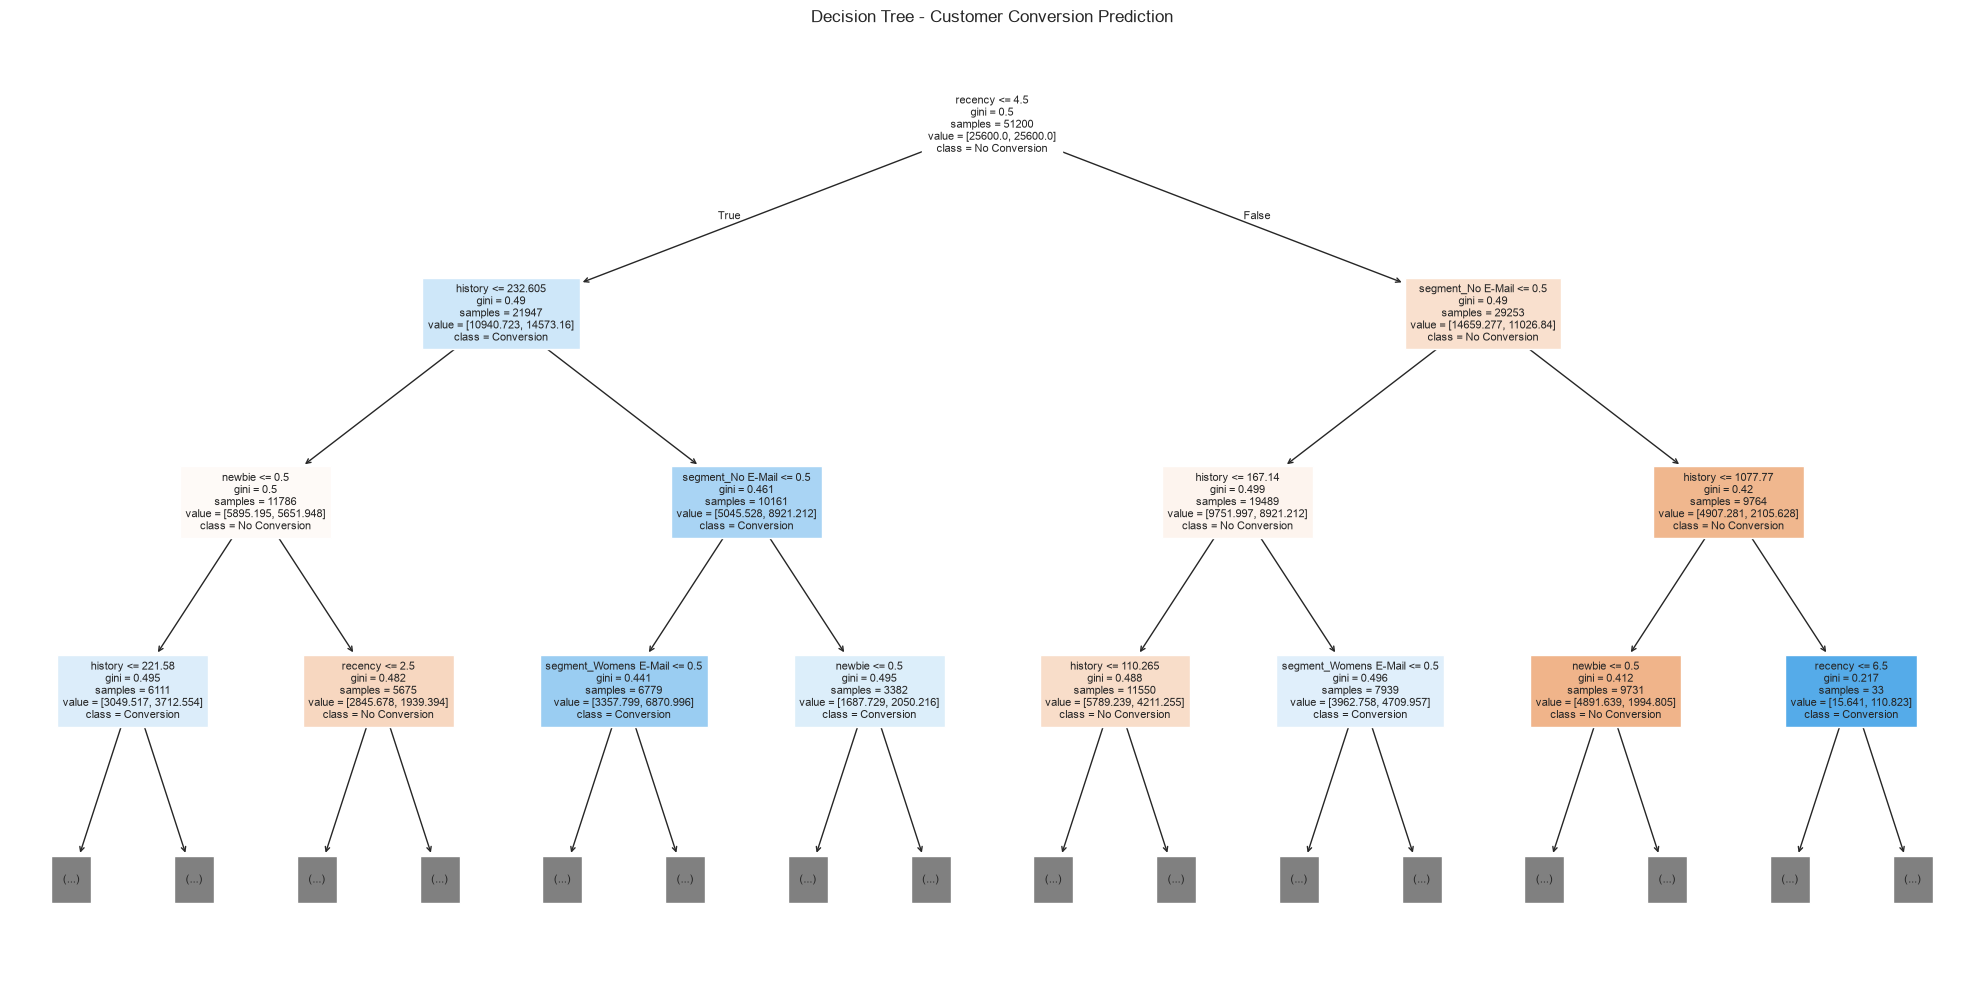

In [35]:

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Conversion", "Conversion"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree - Customer Conversion Prediction")
plt.tight_layout()

plt.savefig(
    "../visualizations/05_decision_tree.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [36]:
model_results = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy_score(y_test, y_pred)]
})

model_results.to_csv(
    "../results/decision_tree_results.csv",
    index=False
)

print("Decision Tree results saved.")

Decision Tree results saved.
